# Retail Customer Prioritization
## RFM Analysis, K-Means Clustering, and Campaign Planning

### Project objective
This project turns transaction-level retail data into customer groups that can guide marketing decisions. It compares possible K-Means cluster counts, profiles the selected clusters, and adds a business flag for **high-value one-time buyers** so that they are not incorrectly treated as loyal repeat customers.

### Questions answered
1. Which customers are active and high value?
2. Which customers are inactive or low-engagement?
3. Are there valuable customers who bought only once and need a different campaign?
4. Does the data support using three, four, or five customer clusters?

## 1. Data source and scope

The project uses the UCI Online Retail dataset: transactions from a UK-based non-store retailer between December 2010 and December 2011. It is a public academic dataset, not data from an Indian business.

**Important limitation:** the results describe this historical retailer only. The workflow can be applied to an Indian retailer when its own transaction data is available, but the segment sizes and spending values should not be assumed to represent Indian customers.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

WORKING_DIRECTORY = Path.cwd().resolve()
if (WORKING_DIRECTORY / "data" / "online_retail.csv").exists():
    PROJECT_ROOT = WORKING_DIRECTORY
elif (WORKING_DIRECTORY.parent / "data" / "online_retail.csv").exists():
    PROJECT_ROOT = WORKING_DIRECTORY.parent
else:
    raise FileNotFoundError(
        "Open this notebook from inside the project folder."
    )

DATA_PATH = PROJECT_ROOT / "data" / "online_retail.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

## 2. Load and inspect the raw transactions

Each row represents one product line in an invoice. A customer can therefore appear on many rows and across many invoices.

In [2]:
raw_df = pd.read_csv(DATA_PATH, parse_dates=["InvoiceDate"])

print(f"Raw rows: {len(raw_df):,}")
print(f"Columns: {raw_df.columns.tolist()}")
print(f"Date range: {raw_df['InvoiceDate'].min()} to {raw_df['InvoiceDate'].max()}")
raw_df.head()

Raw rows: 531,282
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 3. Clean the data

Only transactions that can be linked to a real customer and represent a positive sale are kept. The cleaning summary is retained so the process is transparent and reproducible.

In [3]:
df = raw_df.copy()
cleaning_rows = []

cleaning_rows.append({"Step": "Raw transactions", "Rows remaining": len(df), "Rows removed": 0})

missing_customer = df["CustomerID"].isna() | df["CustomerID"].eq(0)
df = df.loc[~missing_customer].copy()
cleaning_rows.append({
    "Step": "Remove missing or placeholder customer IDs",
    "Rows remaining": len(df),
    "Rows removed": int(missing_customer.sum()),
})

df["InvoiceNo"] = df["InvoiceNo"].astype(str)
cancelled_invoice = df["InvoiceNo"].str.startswith("C")
df = df.loc[~cancelled_invoice].copy()
cleaning_rows.append({
    "Step": "Remove cancelled invoices",
    "Rows remaining": len(df),
    "Rows removed": int(cancelled_invoice.sum()),
})

invalid_sale = (df["Quantity"] <= 0) | (df["UnitPrice"] <= 0)
df = df.loc[~invalid_sale].copy()
cleaning_rows.append({
    "Step": "Remove non-positive quantities or prices",
    "Rows remaining": len(df),
    "Rows removed": int(invalid_sale.sum()),
})

df["CustomerID"] = df["CustomerID"].astype(int)
df["OrderValue"] = df["Quantity"] * df["UnitPrice"]

cleaning_summary = pd.DataFrame(cleaning_rows)
cleaning_summary

,Step,Rows remaining,Rows removed
0,Raw transactions,531282,0
1,Remove missing or placeholder customer IDs,397924,133358
2,Remove cancelled invoices,397924,0
3,Remove non-positive quantities or prices,397884,40


## 4. Explore the cleaned data

These checks describe the business before clustering. They are not used to prove that one segment causes revenue; they show patterns in historical transactions.

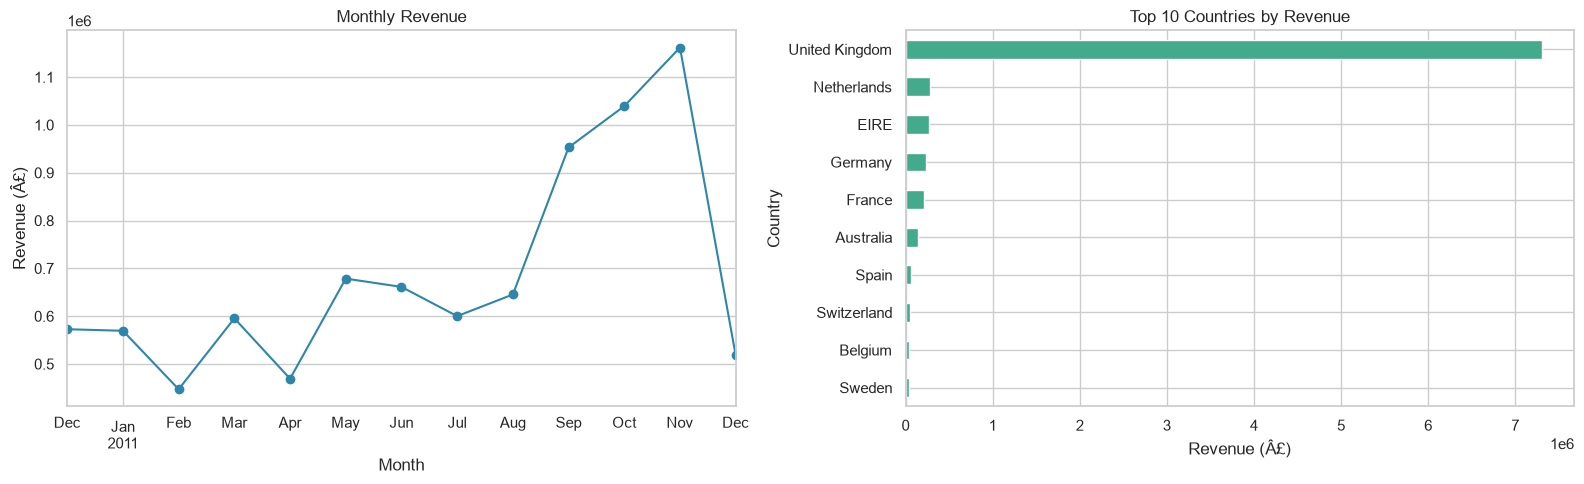

In [4]:
monthly_revenue = df.set_index("InvoiceDate")["OrderValue"].resample("ME").sum()
top_countries = df.groupby("Country")["OrderValue"].sum().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
monthly_revenue.plot(ax=axes[0], marker="o", color="#2E86AB")
axes[0].set(title="Monthly Revenue", xlabel="Month", ylabel="Revenue (Â£)")

top_countries.sort_values().plot(kind="barh", ax=axes[1], color="#43AA8B")
axes[1].set(title="Top 10 Countries by Revenue", xlabel="Revenue (Â£)", ylabel="Country")
plt.tight_layout()
plt.show()

In [5]:
customer_revenue = df.groupby("CustomerID")["OrderValue"].sum().sort_values(ascending=False)
top_ten_percent = max(1, int(len(customer_revenue) * 0.10))
top_ten_share = customer_revenue.head(top_ten_percent).sum() / customer_revenue.sum()

print(
    f"Top 10% of customers ({top_ten_percent:,}) generated {top_ten_share:.1%} of revenue."
)

Top 10% of customers (433) generated 61.3% of revenue.


## 5. Create customer-level features

**Recency** is days since the last order. **Frequency** is the number of distinct invoices. **Monetary** is total spend.

Two additional features make the analysis more useful:

- **AverageOrderValue:** total spend divided by number of orders.
- **ActiveMonths:** number of calendar months in which the customer placed an order.

The high-value one-time-buyer flag is a business rule, not a fifth K-Means cluster. It prevents an unusual but important customer type from being hidden inside a broad cluster.

In [6]:
snapshot_date = df["InvoiceDate"].max().normalize() + pd.Timedelta(days=1)

rfm = (
    df.groupby("CustomerID")
    .agg(
        Recency=("InvoiceDate", lambda dates: (snapshot_date - dates.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("OrderValue", "sum"),
        ActiveMonths=("InvoiceDate", lambda dates: dates.dt.to_period("M").nunique()),
    )
    .reset_index()
)

rfm["AverageOrderValue"] = rfm["Monetary"] / rfm["Frequency"]
high_value_cutoff = rfm["Monetary"].quantile(0.90)
rfm["HighValueOneTimeBuyer"] = (
    rfm["Frequency"].eq(1) & rfm["Monetary"].ge(high_value_cutoff)
)

print(f"Customer summaries created: {len(rfm):,}")
print(f"High-value one-time buyers: {rfm['HighValueOneTimeBuyer'].sum():,}")
rfm.describe().T

Customer summaries created: 4,338
High-value one-time buyers: 7


,count,mean,std,min,25%,50%,75%,max
CustomerID,4338.0,15300.408022,1721.808492,12346.00,13813.250,15299.500,16778.75000,18287.00
Recency,4338.0,92.059474,100.012264,0.00,17.000,50.000,141.75000,373.00
Frequency,4338.0,4.272015,7.697998,1.00,1.000,2.000,5.00000,209.00
Monetary,4338.0,2054.266460,8989.230441,3.75,307.415,674.485,1661.74000,280206.02
ActiveMonths,4338.0,3.009221,2.627853,1.00,1.000,2.000,4.00000,13.00
AverageOrderValue,4338.0,419.166289,1796.537944,3.45,178.625,293.900,430.11375,84236.25


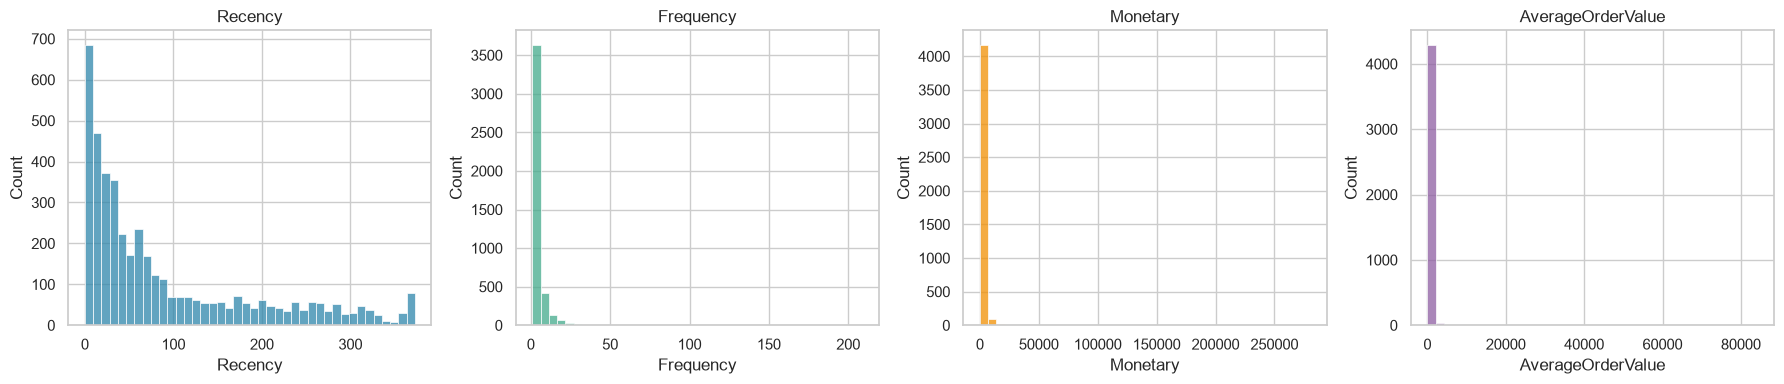

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, column, color in zip(
    axes,
    ["Recency", "Frequency", "Monetary", "AverageOrderValue"],
    ["#2E86AB", "#43AA8B", "#F18F01", "#8E5EA2"],
):
    sns.histplot(rfm[column], bins=40, ax=ax, color=color)
    ax.set_title(column)
plt.tight_layout()
plt.show()

## 6. Prepare RFM for K-Means

Frequency and Monetary are heavily right-skewed, so `log1p` reduces the influence of extreme values. Standardization then gives all three RFM dimensions a comparable scale before K-Means calculates Euclidean distances.

In [8]:
RFM_FEATURES = ["Recency", "Frequency", "Monetary"]
rfm_model = rfm[RFM_FEATURES].copy()
rfm_model["Frequency"] = np.log1p(rfm_model["Frequency"])
rfm_model["Monetary"] = np.log1p(rfm_model["Monetary"])

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_model)
rfm_scaled = pd.DataFrame(rfm_scaled, columns=RFM_FEATURES, index=rfm.index)
rfm_scaled.head()

,Recency,Frequency,Monetary
0,2.329388,-0.955214,3.706225
1,-0.900588,1.074425,1.411843
2,-0.170593,0.386304,0.716489
3,-0.740589,-0.955214,0.698739
4,2.179389,-0.955214,-0.618962


## 7. Compare possible cluster counts

The elbow value (inertia) usually falls as more clusters are added. The silhouette score measures how well-separated the clusters are; higher is better. The final decision considers both the statistics and whether the groups lead to clear, different actions.

In [9]:
evaluation_rows = []
for k in range(2, 7):
    candidate_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    candidate_labels = candidate_model.fit_predict(rfm_scaled)
    evaluation_rows.append(
        {
            "Clusters": k,
            "Inertia": candidate_model.inertia_,
            "SilhouetteScore": silhouette_score(rfm_scaled, candidate_labels),
        }
    )

cluster_evaluation = pd.DataFrame(evaluation_rows)
best_k_by_silhouette = int(
    cluster_evaluation.loc[cluster_evaluation["SilhouetteScore"].idxmax(), "Clusters"]
)

print(f"Best k by silhouette score: {best_k_by_silhouette}")
cluster_evaluation.round(3)

Best k by silhouette score: 3


,Clusters,Inertia,SilhouetteScore
0,2,6871.868,0.406
1,3,4298.758,0.416
2,4,3241.952,0.380
3,5,2760.821,0.343
4,6,2397.521,0.330


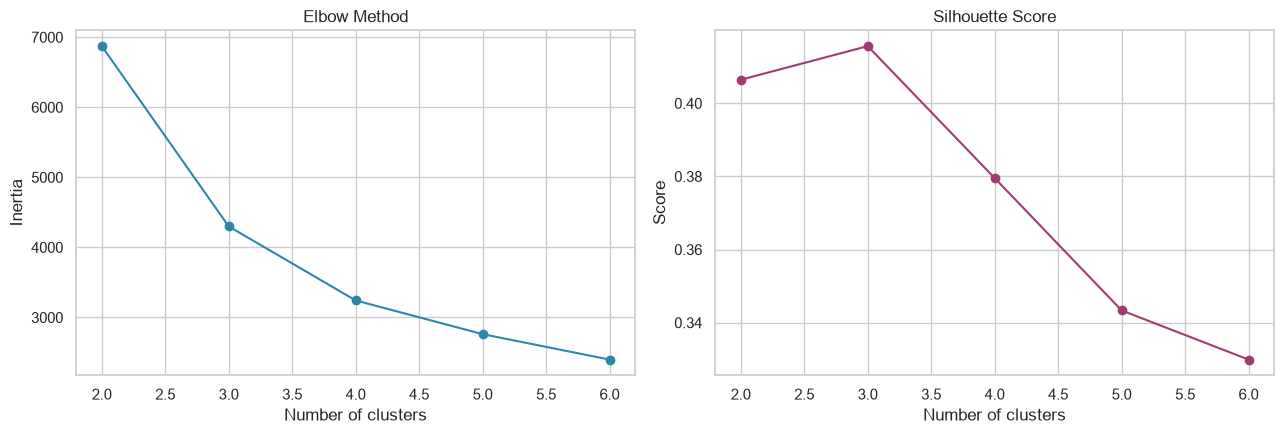

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(cluster_evaluation["Clusters"], cluster_evaluation["Inertia"], marker="o", color="#2E86AB")
axes[0].set(title="Elbow Method", xlabel="Number of clusters", ylabel="Inertia")

axes[1].plot(cluster_evaluation["Clusters"], cluster_evaluation["SilhouetteScore"], marker="o", color="#A23B72")
axes[1].set(title="Silhouette Score", xlabel="Number of clusters", ylabel="Score")
plt.tight_layout()
plt.show()

## 8. Fit and profile the final model

This version uses five K-Means clusters because it provides five understandable customer profiles. The table above must be included in the report: if three clusters has the best silhouette score, that trade-off is stated honestly rather than claiming that four is statistically best.

In [11]:
FINAL_K = 5

kmeans = KMeans(
    n_clusters=FINAL_K,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

## 9. Create honest business segment labels

K-Means cluster IDs are arbitrary numbers. We rank the cluster averages to create readable labels. The previous generic â€œAt Riskâ€ label is replaced with â€œRecent Low-Engagementâ€ because that group has low spending and low order frequency. Customers meeting the high-value one-time rule are highlighted separately.

In [12]:
profile = rfm.groupby("Cluster")[RFM_FEATURES].mean()
r_rank = profile["Recency"].rank(ascending=True)
f_rank = profile["Frequency"].rank(ascending=False)
m_rank = profile["Monetary"].rank(ascending=False)
ordered_clusters = (r_rank + f_rank + m_rank).sort_values().index.tolist()

base_segment_names = [
    "High-Value & Active",
    "Regular Buyers",
    "Recent Low-Engagement",
    "Dormant Customers",
]
cluster_to_segment = dict(zip(ordered_clusters, base_segment_names))

rfm["KMeansSegment"] = rfm["Cluster"].map(cluster_to_segment)
rfm["Segment"] = rfm["KMeansSegment"]
rfm.loc[rfm["HighValueOneTimeBuyer"], "Segment"] = "High-Value One-Time Buyer"

segment_order = [
    "High-Value & Active",
    "Regular Buyers",
    "High-Value One-Time Buyer",
    "Recent Low-Engagement",
    "Dormant Customers",
]

segment_summary = (
    rfm.groupby("Segment")
    .agg(
        Customers=("CustomerID", "size"),
        AverageRecency=("Recency", "mean"),
        AverageFrequency=("Frequency", "mean"),
        AverageSpend=("Monetary", "mean"),
        AverageOrderValue=("AverageOrderValue", "mean"),
        TotalRevenue=("Monetary", "sum"),
    )
    .reindex(segment_order)
    .dropna(how="all")
    .round(1)
)

print("Cluster-to-segment mapping:", cluster_to_segment)
segment_summary

Cluster-to-segment mapping: {1: 'High-Value & Active', 4: 'Regular Buyers', 2: 'Recent Low-Engagement', 0: 'Dormant Customers'}


,Customers,AverageRecency,AverageFrequency,AverageSpend,AverageOrderValue,TotalRevenue
Segment,,,,,,
High-Value & Active,324,14.2,21.3,14415.8,869.4,4670705.1
Regular Buyers,956,31.8,6.2,2548.4,472.5,2436236.2
High-Value One-Time Buyer,7,110.0,1.0,14973.7,14973.7,104816.2
Recent Low-Engagement,1199,60.2,2.7,919.6,408.5,1102650.6
Dormant Customers,898,262.8,1.3,379.4,296.3,340680.4


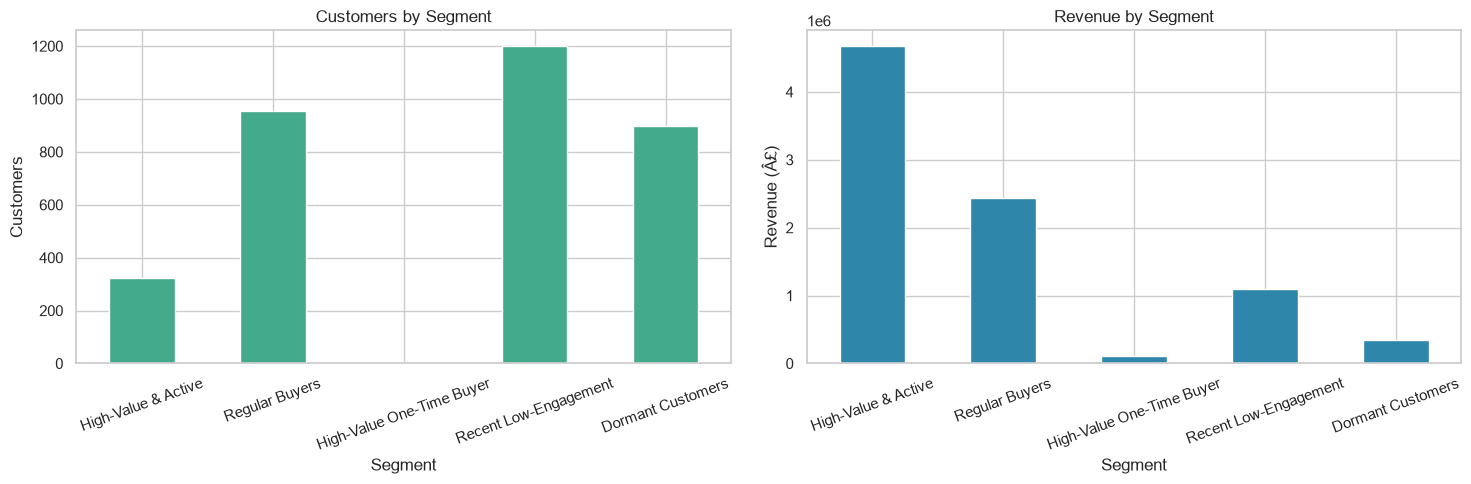

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
segment_summary["Customers"].plot(kind="bar", ax=axes[0], color="#43AA8B")
axes[0].set(title="Customers by Segment", xlabel="Segment", ylabel="Customers")
axes[0].tick_params(axis="x", rotation=20)

segment_summary["TotalRevenue"].plot(kind="bar", ax=axes[1], color="#2E86AB")
axes[1].set(title="Revenue by Segment", xlabel="Segment", ylabel="Revenue (Â£)")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

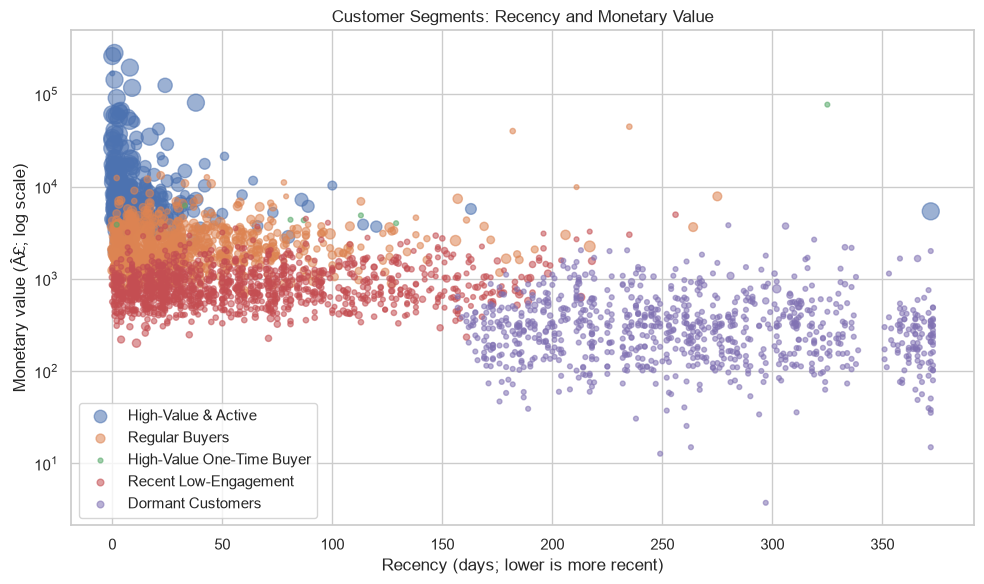

In [14]:
plt.figure(figsize=(10, 6))
for segment in segment_summary.index:
    subset = rfm.loc[rfm["Segment"].eq(segment)]
    plt.scatter(
        subset["Recency"],
        subset["Monetary"],
        s=np.clip(subset["Frequency"] * 5, 12, 150),
        alpha=0.55,
        label=segment,
    )
plt.yscale("log")
plt.title("Customer Segments: Recency and Monetary Value")
plt.xlabel("Recency (days; lower is more recent)")
plt.ylabel("Monetary value (Â£; log scale)")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Campaign recommendations

| Segment | Business interpretation | Recommended action |
|---|---|---|
| High-Value & Active | Recent, frequent, high-spending customers | Retain with loyalty rewards, early access, and referrals. |
| Regular Buyers | Customers with repeat purchasing behaviour | Cross-sell related products and encourage a next purchase. |
| High-Value One-Time Buyer | Large single purchase but no repeat behaviour | Send a personal follow-up or relevant product recommendation. |
| Recent Low-Engagement | Recently seen but with limited purchasing activity | Use a low-cost welcome-back or second-purchase offer. |
| Dormant Customers | Long time since purchase and low activity | Use inexpensive re-engagement; avoid costly individual outreach. |

These are proposed actions based on historical behaviour. The dataset has no campaign-response data, so it cannot prove that a campaign will cause a sale.

## 11. Export results for the dashboard

The dashboard reads the customer-level file and the cluster-evaluation file. Re-run this notebook from top to bottom whenever the analysis changes.

In [15]:
OUTPUT_DIR.mkdir(exist_ok=True)
customer_output_path = OUTPUT_DIR / "customer_segments.csv"
evaluation_output_path = OUTPUT_DIR / "cluster_evaluation.csv"

rfm.to_csv(customer_output_path, index=False)
cluster_evaluation.to_csv(evaluation_output_path, index=False)

print(f"Saved customer segments to: {customer_output_path}")
print(f"Saved cluster evaluation to: {evaluation_output_path}")
print(f"Exported columns: {rfm.columns.tolist()}")

Saved customer segments to: C:\Users\svish\Downloads\Customer-Segmentation-Dashboard-main\Customer-Segmentation-Dashboard-main\outputs\customer_segments.csv
Saved cluster evaluation to: C:\Users\svish\Downloads\Customer-Segmentation-Dashboard-main\Customer-Segmentation-Dashboard-main\outputs\cluster_evaluation.csv
Exported columns: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'ActiveMonths', 'AverageOrderValue', 'HighValueOneTimeBuyer', 'Cluster', 'KMeansSegment', 'Segment']


## 12. Limitations and conclusion

- The dataset is historical and belongs to a UK retailer, so results are not automatically generalizable to Indian retail.
- K-Means groups similar historical purchasing patterns; it does not predict future spending or campaign success.
- The high-value one-time-buyer flag is intentionally rule-based and transparent.
- A real business should validate campaign ideas through controlled testing, such as comparing campaign responses with a similar untreated group.

The project demonstrates an end-to-end, reproducible workflow: clean transactions, build customer features, evaluate a clustering choice, translate outputs into careful business segments, and present them in a dashboard.